# Predictive Maintenance — Turbofan Engine Health Classification

**Dataset**: NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)  
**Source**: [Kaggle — behrad3d/nasa-cmaps](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps)  
**Task**: Multi-class health classification — *Healthy / Degrading / Critical*  
**Models**: XGBoost (tabular rolling features) · LSTM (sensor time-series sequences)  
**Processing**: PySpark for scalable feature engineering  

---

The C-MAPSS dataset simulates turbofan engine degradation under varying operating conditions.
Four sub-datasets (FD001–FD004) differ in the number of operating regimes (1 or 6) and
fault modes (1 or 2).  Each row is one engine cycle with readings from 21 sensors.
The objective is to classify the current health state of an engine from its sensor history,
enabling early intervention before catastrophic failure.

**Health-state encoding**  
RUL (Remaining Useful Life) is derived from training run-to-failure data:
- `Healthy (0)` : capped RUL > 80 cycles  
- `Degrading (1)` : 30 < capped RUL ≤ 80 cycles  
- `Critical (2)` : capped RUL ≤ 30 cycles  

In [1]:
# =========================================================
# 0. Imports & Configuration
# =========================================================

# --- Standard library ---
import importlib.util
import sys
import warnings
from pathlib import Path

# --- Third-party core ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# --- AutoML & experiment tracking ---
import mlflow
import mlflow.sklearn

# --- SHAP ---
import shap

# --- Project utils ---
def _load_module(name: str, rel_path: str):
    """Dynamically load a utility module by relative file path."""
    spec = importlib.util.spec_from_file_location(name, Path(rel_path))
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    sys.modules[name] = mod
    return mod

plot_style = _load_module("plot_style", "utils/plot_style.py")
from plot_style import (  # noqa: E402
    apply_style, FigSize,
    CMAP, C1, C2, C3,
    CMAP_DMG, D1, D2, D3,
    CMAP_IR,  I1, I2, I3,
    blues, salmons, greens,
)

from utils.download_dataset import get_data_dir
from utils.data_loader import (
    load_all_fds, compute_rul, attach_test_rul,
    USEFUL_SENSORS, OP_SETTINGS,
    CLASS_NAMES, RUL_CAP, RUL_HEALTHY_THR, RUL_CRITICAL_THR,
)
from utils.feature_engineering import (
    add_rolling_features_spark, add_cycle_normalisation_spark,
    min_max_normalise_spark, apply_min_max_spark,
    create_lstm_sequences, get_feature_cols,
    DEFAULT_WINDOW_SIZE,
)
from utils.ml_classification import (
    run_automl_with_mlflow,
    build_lstm_model, train_lstm,
    evaluate_classification, get_confusion_matrix,
    save_model, load_model,
)

warnings.filterwarnings("ignore")
apply_style()

c:\Users\20215518\Anaconda3\envs\ds-py311\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [2]:
# --- Global constants (Section 0 — change here and re-run) ---

RANDOM_STATE = 42       # global seed — never change between notebooks
TEST_SIZE    = 0.20     # held-out test fraction
N_SPLITS     = 5        # cross-validation folds (used by FLAML internally)

# Dataset configuration
FD_IDS          = [1, 2, 3, 4]   # sub-datasets to include
DATA_DIR        = "data/raw"      # local raw data directory

# Feature engineering
WINDOW_SIZE     = DEFAULT_WINDOW_SIZE   # rolling window length (30 cycles)
LSTM_SEQ_LEN    = 30                    # LSTM input sequence length

# Health-class thresholds (mirrors data_loader defaults)
RUL_CAP_VAL         = RUL_CAP           # 125
RUL_HEALTHY_VAL     = RUL_HEALTHY_THR   # 80
RUL_CRITICAL_VAL    = RUL_CRITICAL_THR  # 30

# AutoML (FLAML) — FLAML searches LightGBM, XGBoost, RF, Extra Trees, linear
AUTOML_TIME_BUDGET  = 300              # search budget in seconds (increase for better results)
AUTOML_METRIC       = "f1_weighted"    # optimisation objective
MLFLOW_EXPERIMENT   = "turbofan-health-classification"
MLFLOW_TRACKING_URI = "./mlruns"       # local file-based tracking — no server required

# LSTM — set ENABLE_LSTM = True to activate (requires TensorFlow)
ENABLE_LSTM         = False
LSTM_UNITS          = [128, 64]
LSTM_DROPOUT        = 0.2
LSTM_EPOCHS         = 50
LSTM_BATCH          = 256
LSTM_PATIENCE       = 10

# SHAP
SHAP_SAMPLE_SIZE    = 500
SHAP_CLASS          = 2    # Critical — most actionable class for maintenance decisions

# Output paths
MODEL_DIR           = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
ASSETS_DIR          = Path("assets")
ASSETS_DIR.mkdir(exist_ok=True)

# Colour mapping for health classes (consistent across all plots)
CLASS_COLORS  = {"Healthy": C1, "Degrading": D1, "Critical": I1}
CLASS_PALETTE = [C1, D1, I1]

## 1. Data Acquisition

The NASA C-MAPSS dataset is downloaded via `kagglehub` (cached after the first run).
If data is already present in `data/raw/`, the download is skipped.
All four sub-datasets (FD001–FD004) are loaded and concatenated into a single
pandas DataFrame.

In [3]:
# =========================================================
# 1. Data Acquisition
# =========================================================

# --- 1a. Download / locate dataset ---
data_dir = get_data_dir(DATA_DIR)
print(f"\nData directory : {data_dir}")

Local data found at: data\raw

Data directory : data\raw


In [4]:
# --- 1b. Load raw training data ---
df_raw = load_all_fds(data_dir, fds=FD_IDS, split="train")

print(f"Raw training rows : {len(df_raw):,}")
print(f"Columns           : {df_raw.shape[1]}")
display(df_raw.iloc[200:210])

# Build df_eda so Section 2 has labelled data available
# compute_rul is called again in Section 3 as the canonical df_labelled
df_eda = compute_rul(df_raw)
df_eda["health_label"] = df_eda["health_class"].map(dict(enumerate(CLASS_NAMES)))

Raw training rows : 160,359
Columns           : 27


,unit_nr,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,fd_id
200,1002,9,0.0017,-0.0004,100.0,518.67,641.98,1581.99,1395.01,14.62,...,2387.98,8145.29,8.3868,0.03,390,2388,100.0,39.06,23.4875,1
201,1002,10,-0.0045,0.0002,100.0,518.67,641.99,1586.37,1394.86,14.62,...,2387.97,8138.64,8.3982,0.03,391,2388,100.0,39.20,23.6005,1
202,1002,11,0.0006,0.0004,100.0,518.67,642.26,1589.21,1401.29,14.62,...,2388.03,8135.85,8.4188,0.03,392,2388,100.0,39.23,23.3888,1
203,1002,12,0.0002,0.0006,100.0,518.67,641.64,1579.99,1401.90,14.62,...,2387.97,8136.49,8.3925,0.03,392,2388,100.0,39.12,23.4201,1
204,1002,13,0.0007,0.0005,100.0,518.67,641.78,1586.77,1401.53,14.62,...,2387.99,8140.61,8.3742,0.03,391,2388,100.0,38.88,23.4317,1
205,1002,14,-0.0024,-0.0004,100.0,518.67,641.66,1584.04,1395.46,14.62,...,2387.98,8140.09,8.3887,0.03,391,2388,100.0,38.93,23.4074,1
206,1002,15,-0.0012,-0.0003,100.0,518.67,642.21,1579.84,1402.11,14.62,...,2388.02,8137.72,8.3704,0.03,393,2388,100.0,38.94,23.4311,1
207,1002,16,-0.0010,0.0003,100.0,518.67,641.81,1581.99,1393.46,14.62,...,2387.95,8133.45,8.3805,0.03,392,2388,100.0,39.01,23.4462,1
208,1002,17,0.0003,-0.0001,100.0,518.67,642.43,1583.58,1390.27,14.62,...,2388.08,8134.78,8.3714,0.03,391,2388,100.0,39.04,23.5245,1
209,1002,18,0.0014,0.0001,100.0,518.67,641.95,1588.43,1400.25,14.62,...,2388.00,8133.20,8.4053,0.03,391,2388,100.0,39.00,23.4203,1


### Data Structure

Each row represents **one engine cycle** (one timestep for one engine unit).
The raw file has no header — columns are assigned by position:

| Group | Columns | Count | Description |
|---|---|---|---|
| **Identity** | `unit_nr`, `time_cycles` | 2 | Engine ID (globally unique) · cycle index (1 → failure) |
| **Operational settings** | `op_setting_1/2/3` | 3 | Throttle resolver angle, altitude, Mach number |
| **Sensors** | `sensor_01` – `sensor_21` | 21 | Thermodynamic measurements (temps, pressures, speeds, ratios) |
| **Provenance** | `fd_id` | 1 | Sub-dataset index (1–4) — added on load |

**Key sensors used** (7 near-constant sensors dropped based on literature):

| Sensor | Physical meaning |
|---|---|
| s02 | LPC outlet temperature (°R) |
| s03 | HPC outlet temperature (°R) |
| s04 | LPT outlet temperature (°R) |
| s07 | HPC outlet static pressure (psia) |
| s08 | Fuel flow ratio (pps/psia) |
| s09 | Bypass ratio |
| s11 | HPC outlet static pressure (psia) |
| s12 | Ratio of fuel flow to Ps30 |
| s13 | Corrected core speed (rpm) |
| s14 | Corrected fan speed (rpm) |
| s15 | HPT coolant bleed (lbm/s) |
| s17 | Demanded fan speed (rpm) |
| s20 | Demanded corrected fan speed (rpm) |
| s21 | HPT coolant bleed (lbm/s) |

**Sub-dataset characteristics:**

| FD | Operating conditions | Fault modes | Train engines |
|---|---|---|---|
| FD001 | 1 | 1 (HPC degradation) | 100 |
| FD002 | 6 | 1 (HPC degradation) | 260 |
| FD003 | 1 | 2 (HPC + fan degradation) | 100 |
| FD004 | 6 | 2 (HPC + fan degradation) | 249 |

,Group,Count,Columns,dtype,example (row 0)
0,Identity,2,"unit_nr, time_cycles",int64,"[1001, 1]"
1,Operational settings,3,"op_setting_1, op_setting_2, op_setting_3",float64,"[-0.0007, -0.0004, 100.0]"
2,Sensors (dropped),7,"sensor_01, sensor_05, sensor_06, sensor_10, se...",float64,"[518.67, 14.62, 21.61, 1.3, 0.03, 2388.0, 100.0]"
3,Sensors (used),14,"sensor_02, sensor_03, sensor_04, sensor_07, se...",float64,"[641.82, 1589.7, 1400.6, 554.36, 2388.06, 9046..."
4,Provenance,1,fd_id,int64,[1]



Engines (train)     : 709
Life per engine     : min=128, median=207, max=543 cycles
Total rows          : 160,359


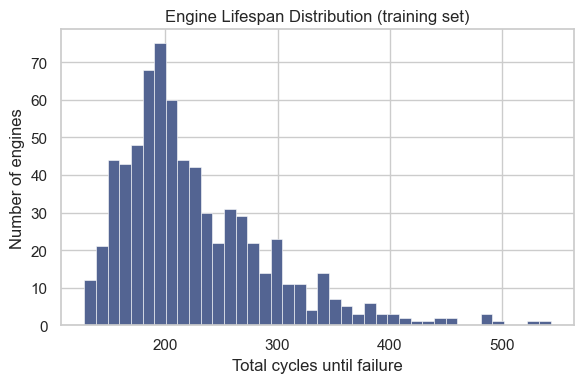

In [5]:
# --- 1c. Column-group summary ---
col_groups = {
    "Identity":             ["unit_nr", "time_cycles"],
    "Operational settings": [c for c in df_raw.columns if c.startswith("op_setting")],
    "Sensors (dropped)":    [f"sensor_{i:02d}" for i in [1, 5, 6, 10, 16, 18, 19]],
    "Sensors (used)":       USEFUL_SENSORS,
    "Provenance":           ["fd_id"],
}

summary = pd.DataFrame([
    {
        "Group":   grp,
        "Count":   len(cols),
        "Columns": ", ".join(cols),
        "dtype":   df_raw[cols].dtypes.unique()[0].name,
        "example (row 0)": df_raw[cols].iloc[0].tolist(),
    }
    for grp, cols in col_groups.items()
])
display(summary)

# --- Engine lifespan distribution ---
life_stats = df_raw.groupby("unit_nr")["time_cycles"].max()
print(f"\nEngines (train)     : {df_raw['unit_nr'].nunique()}")
print(f"Life per engine     : min={life_stats.min()}, median={life_stats.median():.0f}, max={life_stats.max()} cycles")
print(f"Total rows          : {len(df_raw):,}")

fig, ax = plt.subplots(figsize=FigSize.DEFAULT)
ax.hist(life_stats.values, bins=40, color=C2, edgecolor="white", linewidth=0.4)
ax.set_title("Engine Lifespan Distribution (training set)")
ax.set_xlabel("Total cycles until failure")
ax.set_ylabel("Number of engines")
plt.tight_layout()
plt.show()

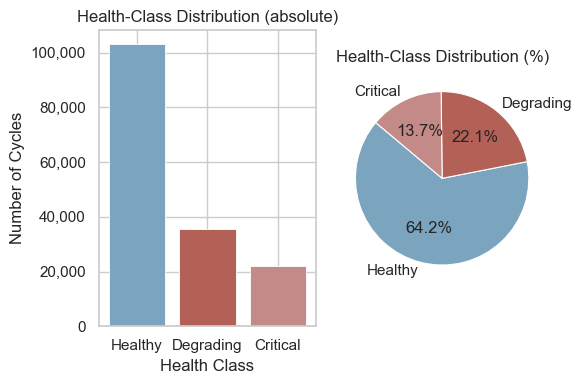

In [6]:
# --- 2a. Health-class distribution ---
fig, axes = plt.subplots(1, 2, figsize=FigSize.DEFAULT)

counts = df_eda["health_label"].value_counts().reindex(CLASS_NAMES)
axes[0].bar(CLASS_NAMES, counts.values, color=CLASS_PALETTE, edgecolor="white", linewidth=0.6)
axes[0].set_title("Health-Class Distribution (absolute)")
axes[0].set_xlabel("Health Class")
axes[0].set_ylabel("Number of Cycles")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

pct = (counts / counts.sum() * 100).round(1)
axes[1].pie(pct.values, labels=CLASS_NAMES, colors=CLASS_PALETTE,
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 0.8})
axes[1].set_title("Health-Class Distribution (%)")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "rul_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

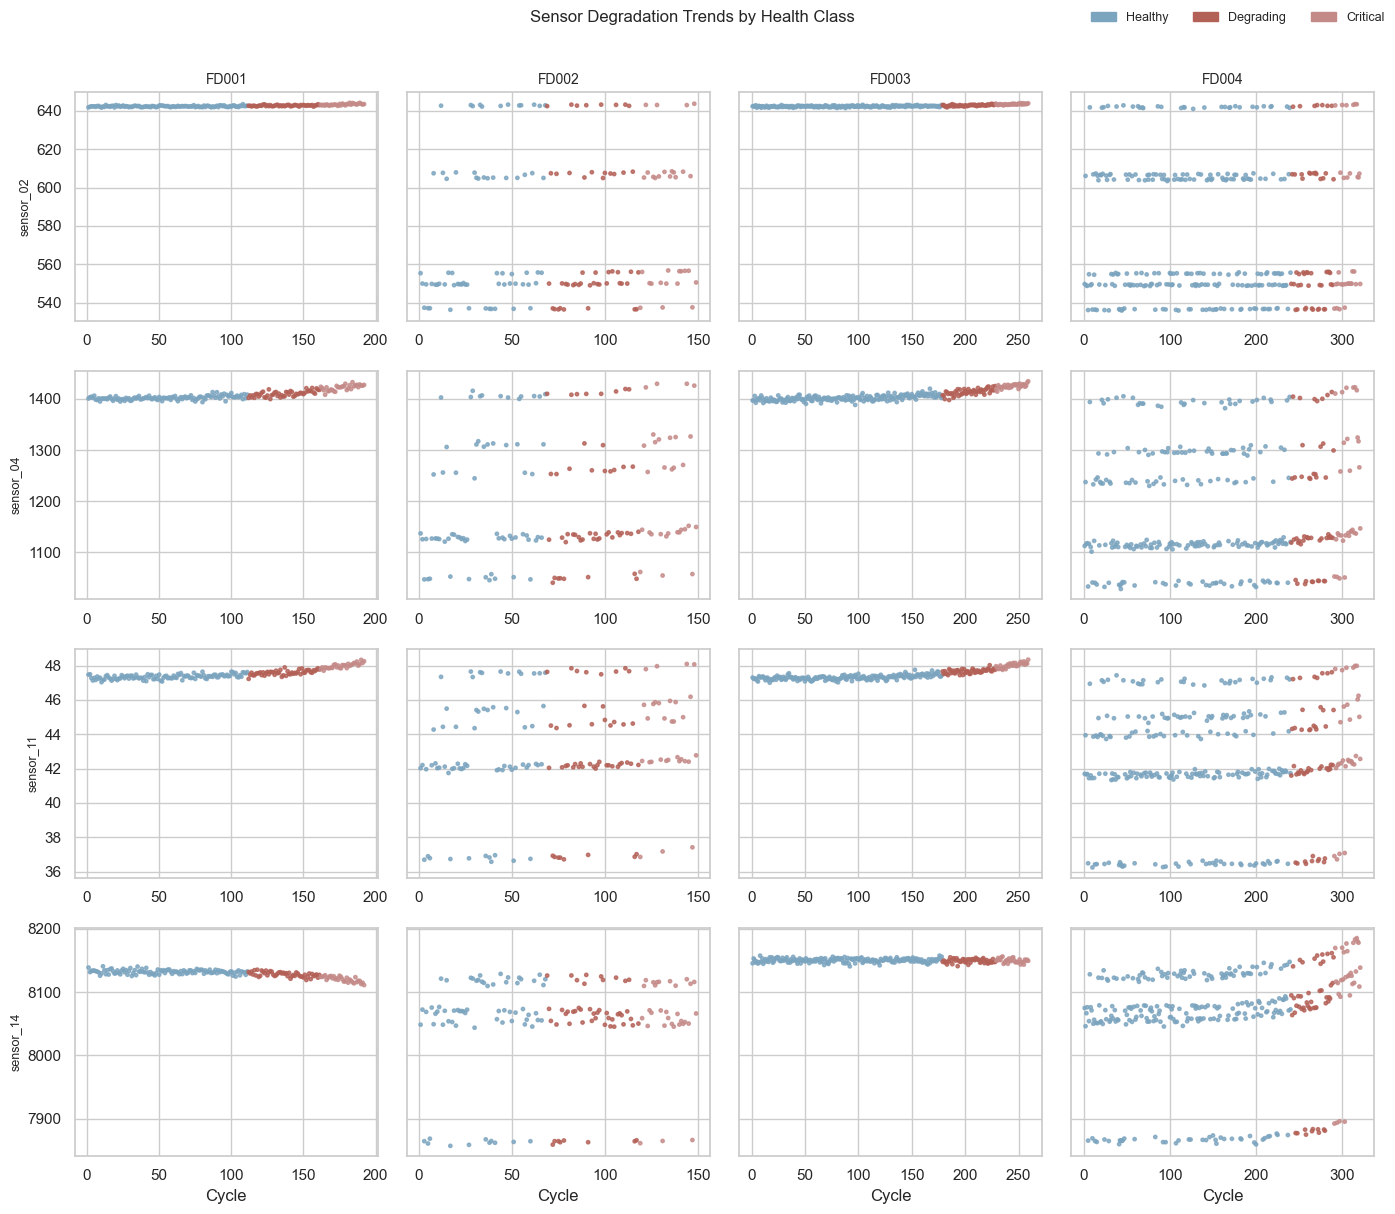

In [7]:
# --- 2b. Sensor degradation trend for one representative unit per FD dataset ---
SAMPLE_SENSORS  = ["sensor_02", "sensor_04", "sensor_11", "sensor_14"]
SAMPLE_FD_UNITS = [df_eda[df_eda["fd_id"] == fd]["unit_nr"].iloc[0] for fd in FD_IDS]

fig, axes = plt.subplots(len(SAMPLE_SENSORS), len(FD_IDS),
                          figsize=(14, 3 * len(SAMPLE_SENSORS)), sharey="row")

for row_i, sensor in enumerate(SAMPLE_SENSORS):
    for col_i, (fd, unit) in enumerate(zip(FD_IDS, SAMPLE_FD_UNITS)):
        ax   = axes[row_i][col_i]
        unit_df = df_eda[df_eda["unit_nr"] == unit].sort_values("time_cycles")
        color = [CLASS_COLORS[lbl] for lbl in unit_df["health_label"]]
        ax.scatter(unit_df["time_cycles"], unit_df[sensor], c=color, s=6, alpha=0.8)
        if row_i == 0:
            ax.set_title(f"FD{fd:03d}", fontsize=10)
        if col_i == 0:
            ax.set_ylabel(sensor, fontsize=9)
        ax.set_xlabel("Cycle" if row_i == len(SAMPLE_SENSORS) - 1 else "")

# Legend patches
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in CLASS_COLORS.items()]
fig.legend(handles=legend_handles, loc="upper right", ncol=3,
           frameon=False, fontsize=9)
fig.suptitle("Sensor Degradation Trends by Health Class", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "sensor_degradation_trends.png", dpi=150, bbox_inches="tight")
plt.show()

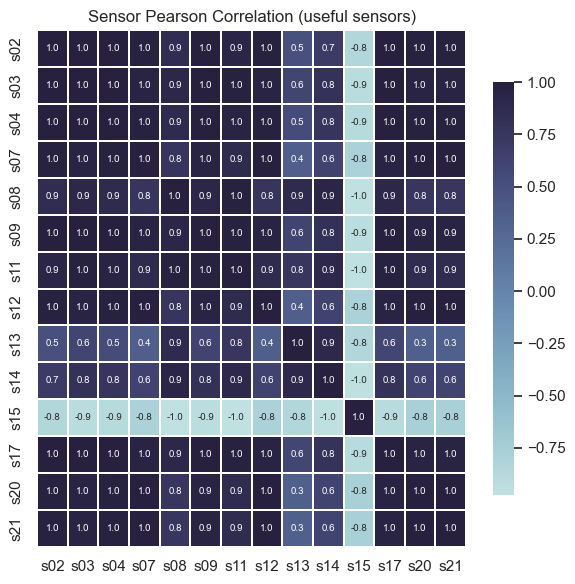

In [8]:
# --- 2c. Sensor correlation heatmap (useful sensors only) ---
sensor_short = [s.replace("sensor_", "s") for s in USEFUL_SENSORS]
corr_matrix  = df_eda[USEFUL_SENSORS].rename(
    columns=dict(zip(USEFUL_SENSORS, sensor_short))
).corr()

fig, ax = plt.subplots(figsize=FigSize.HEATMAP_LARGE)
sns.heatmap(
    corr_matrix, annot=True, fmt=".1f", cmap=CMAP,
    center=0, linewidths=0.3, ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Sensor Pearson Correlation (useful sensors)")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "sensor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

**EDA summary**

- The *Healthy* class dominates (engines spend most of their life in good health),
  creating mild class imbalance that we address by using F1-weighted for model selection.
- Key sensors (s02, s04, s11, s14) show clear monotonic trends as engines degrade —
  confirming that rolling-window statistics will be informative features.
- Several sensors are highly correlated (> 0.9) — XGBoost's column sub-sampling
  (`colsample_bytree`) naturally handles this; LSTM learns inter-sensor relationships
  through its recurrent gates.

## 3. Preprocessing Pipeline

All feature engineering is done in pandas:
1. **RUL computation** — `max(time_cycles) − time_cycles` per unit, capped at 125.
2. **Health-class assignment** — threshold-based mapping from capped RUL.
3. **Rolling-window features** — per-sensor mean/std/min/max/delta over 30-cycle windows.
4. **Cycle normalisation** — `time_cycles / max_cycles` per unit.
5. **Min-max scaling** — fit on training split only (prevents leakage).
6. **Train/test split** — stratified by health class.

The final DataFrame is used directly for XGBoost; sensor sequences are reshaped
into 3-D tensors `(n_samples, seq_len, n_features)` for LSTM.

In [9]:
# =========================================================
# 3. Preprocessing Pipeline
# =========================================================

# --- 3a. RUL + health-class labels ---
df_labelled = compute_rul(
    df_raw,
    rul_cap=RUL_CAP_VAL,
    healthy_thr=RUL_HEALTHY_VAL,
    critical_thr=RUL_CRITICAL_VAL,
)
print("Health-class counts:")
display(
    df_labelled["health_class"]
    .value_counts()
    .rename(index=dict(enumerate(CLASS_NAMES)))
    .to_frame("count")
)

Health-class counts:


,count
health_class,
Healthy,102930
Degrading,35450
Critical,21979


In [10]:
# --- 3b. Rolling-window features ---
df_feat = add_rolling_features_spark(
    df_labelled,
    sensor_cols=USEFUL_SENSORS,
    window_size=WINDOW_SIZE,
    include_delta=True,
)
# norm_cycle excluded — it encodes lifecycle position derived from the failure point,
# which constitutes target leakage (RUL is the label; norm_cycle ≈ 1 − RUL/lifespan)

feature_cols = get_feature_cols(
    USEFUL_SENSORS,
    include_delta=True,
    include_norm_cycle=False,
    include_op_settings=True,
)
print(f"Feature columns : {len(feature_cols)}")
print(feature_cols[:10], "…")

Feature columns : 73
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_02_mean', 'sensor_02_std', 'sensor_02_min', 'sensor_02_max', 'sensor_02_delta', 'sensor_03_mean', 'sensor_03_std'] …


In [11]:
# --- 3c. Min-max normalise features (fit on training data only) ---
df_scaled, scale_params = min_max_normalise_spark(df_feat, feature_cols)
print("Min-max normalisation complete.")

Min-max normalisation complete.


In [12]:
# --- 3d. Finalise DataFrame ---
KEEP_COLS = ["unit_nr", "time_cycles", "fd_id", "health_class"] + USEFUL_SENSORS + feature_cols
KEEP_COLS = list(dict.fromkeys(KEEP_COLS))  # deduplicate, preserve order

df = (
    df_scaled[KEEP_COLS]
    .sort_values(["unit_nr", "time_cycles"])
    .reset_index(drop=True)
)
df["health_label"] = df["health_class"].map(dict(enumerate(CLASS_NAMES)))

print(f"Final DataFrame shape : {df.shape}")
display(df[feature_cols[:5] + ["health_class"]].head(3))

Final DataFrame shape : (160359, 92)


,op_setting_1,op_setting_2,op_setting_3,sensor_02_mean,sensor_02_std,health_class
0,0.000190,0.000237,1.0,0.983232,0.000000,0
1,0.000252,0.000356,1.0,0.984764,0.003091,0
2,0.000105,0.001068,1.0,0.985894,0.003545,0


In [13]:
# --- 3e. Train / test split (stratified by health class) ---
X = df[feature_cols].values
y = df["health_class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train : {X_train.shape}  X_test : {X_test.shape}")
print(f"Class balance (train) — ", dict(zip(*np.unique(y_train, return_counts=True))))
print(f"Class balance (test)  — ", dict(zip(*np.unique(y_test,  return_counts=True))))

X_train : (128287, 73)  X_test : (32072, 73)
Class balance (train) —  {0: 82344, 1: 28360, 2: 17583}
Class balance (test)  —  {0: 20586, 1: 7090, 2: 4396}


In [14]:
# --- 3f. LSTM sequence construction ---
# Use df (already min-max normalised in Section 3c) with all 73 rolling features.
# This gives LSTM the same feature information as XGBoost, allowing a fair comparison.

df_lstm_all = df[["unit_nr", "time_cycles", "health_class"] + feature_cols].copy()

X_seq, y_seq = create_lstm_sequences(
    df_lstm_all,
    sensor_cols=feature_cols,          # 73 engineered features, not just raw sensors
    label_col="health_class",
    seq_len=LSTM_SEQ_LEN,
)

X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(
    X_seq, y_seq,
    test_size=TEST_SIZE,
    stratify=y_seq,
    random_state=RANDOM_STATE,
)
# Further split training into train / validation for LSTM early stopping
X_seq_tr, X_seq_val, y_seq_tr, y_seq_val = train_test_split(
    X_seq_train, y_seq_train,
    test_size=0.15,
    stratify=y_seq_train,
    random_state=RANDOM_STATE,
)

# Compute class weights to prevent majority-class collapse (Healthy dominates ~59%)
cw = compute_class_weight("balanced", classes=np.unique(y_seq_tr), y=y_seq_tr)
lstm_class_weight = dict(enumerate(cw))
print(f"Class weights: { {CLASS_NAMES[i]: round(w, 3) for i, w in lstm_class_weight.items()} }")

print(f"LSTM sequences — train: {X_seq_tr.shape}  val: {X_seq_val.shape}  test: {X_seq_test.shape}")

Class weights: {'Healthy': 0.566, 'Degrading': 1.314, 'Critical': 2.12}
LSTM sequences — train: (95062, 30, 73)  val: (16776, 30, 73)  test: (27960, 30, 73)


## 4. Model Definition

Two approaches are compared:

| Model | Input | Rationale |
|---|---|---|
| **FLAML AutoML** | Flat rolling-feature vector (73 features, tabular) | Automated search over LightGBM, XGBoost, RF, Extra Trees and linear models within a fixed time budget; best algorithm + hyperparameters selected by F1-weighted CV; every trial logged to MLflow |
| **LSTM** | Rolling-feature sequence `(30 cycles × 73 features)` | Captures temporal dependencies across consecutive cycles; same 73 features as AutoML for a fair comparison |

Both models see identical engineered features — the difference is *how* they consume them:
AutoML treats each cycle independently as a flat vector; LSTM sees 30 consecutive cycles as a sequence.

**Why FLAML?**
FLAML (Fast and Lightweight AutoML) uses cost-frugal optimisation to allocate more
search budget to promising model families early, making it significantly faster than
random or grid search for the same wall-clock budget.

In [15]:
# =========================================================
# 4. Model Definition
# =========================================================

# --- 4a. FLAML AutoML — configure MLflow experiment ---
# The AutoML object is instantiated and fitted in Section 5 (inside the MLflow run).
# Here we verify the tracking URI is reachable and print the experiment name.
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment name     : {MLFLOW_EXPERIMENT}")
print(f"AutoML time budget  : {AUTOML_TIME_BUDGET}s  |  metric: {AUTOML_METRIC}")
print(f"Models searched     : LightGBM, XGBoost, RandomForest, ExtraTrees, linear")

MLflow tracking URI : ./mlruns
Experiment name     : turbofan-health-classification
AutoML time budget  : 300s  |  metric: f1_weighted
Models searched     : LightGBM, XGBoost, RandomForest, ExtraTrees, linear


In [16]:
# --- 4b. LSTM model (optional — set ENABLE_LSTM = True in Section 0 to activate) ---
_lstm_available = False

if ENABLE_LSTM:
    try:
        lstm_model = build_lstm_model(
            seq_len=LSTM_SEQ_LEN,
            n_features=len(feature_cols),  # 73 rolling features (same as XGBoost input)
            n_classes=len(CLASS_NAMES),
            lstm_units=LSTM_UNITS,
            dropout_rate=LSTM_DROPOUT,
            random_state=RANDOM_STATE,
        )
        lstm_model.summary()
        _lstm_available = True
    except RuntimeError as e:
        print(f"LSTM unavailable: {e}")
else:
    print("LSTM disabled — set ENABLE_LSTM = True in Section 0 to activate.")

LSTM disabled — set ENABLE_LSTM = True in Section 0 to activate.


## 5. Cross-Validation & Model Selection

**FLAML AutoML**: Searches over LightGBM, XGBoost, Random Forest, Extra Trees and
linear models within the `AUTOML_TIME_BUDGET` second wall-clock budget.  Internally,
FLAML evaluates each candidate using cross-validation on the training set.  Every
trial is logged to MLflow; the best model is registered as a versioned artifact.

Model selection is based entirely on CV F1-weighted — the test set remains untouched
until Section 6.

**LSTM**: A single 85/15 train/validation split with early stopping and
ReduceLROnPlateau callbacks.  Full k-fold CV for deep networks is computationally
prohibitive; we monitor `val_loss` across epochs instead.

In [17]:
# =========================================================
# 5. Cross-Validation & Model Selection
# =========================================================

# --- 5a. FLAML AutoML — search + MLflow logging ---
# run_automl_with_mlflow wraps the full FLAML search inside a single MLflow run.
# extra_params logs all Section 0 constants for complete reproducibility.
print(f"Starting FLAML AutoML search ({AUTOML_TIME_BUDGET}s budget)…")

automl, cv_results = run_automl_with_mlflow(
    X_train, y_train,
    time_budget      = AUTOML_TIME_BUDGET,
    metric           = AUTOML_METRIC,
    experiment_name  = MLFLOW_EXPERIMENT,
    tracking_uri     = MLFLOW_TRACKING_URI,
    extra_params     = {
        "fd_ids":           str(FD_IDS),
        "window_size":      WINDOW_SIZE,
        "n_features":       len(feature_cols),
        "rul_cap":          RUL_CAP_VAL,
        "rul_healthy_thr":  RUL_HEALTHY_VAL,
        "rul_critical_thr": RUL_CRITICAL_VAL,
        "test_size":        TEST_SIZE,
    },
    random_state = RANDOM_STATE,
    scale_params = scale_params,   # saves models/scale_params.json for /predict_raw API endpoint
)

# Assign to best_pipeline to follow portfolio variable-name convention
best_pipeline = automl

print("\nPer-estimator CV results (best F1-weighted per model family):")
display(cv_results)

Starting FLAML AutoML search (300s budget)…
  scale_params    : saved to models/scale_params.json (73 cols)

  FLAML AutoML — Search Complete
  MLflow run ID   : dbf7f0cf4ac447c8b120ef2942da3647
  Best estimator  : lgbm
  CV F1-weighted  : 0.9873  (1 − best_loss)
  Best config     : {'n_estimators': 2547, 'num_leaves': 10, 'min_child_samples': 99, 'learning_rate': 0.6763335282110124, 'log_max_bin': 8, 'colsample_bytree': 0.5176453202619683, 'reg_alpha': 0.7498553066576009, 'reg_lambda': 3.493454550980352}

Per-estimator CV results (best F1-weighted per model family):


Registered model 'turbofan-health-classification' already exists. Creating a new version of this model...
Created version '7' of model 'turbofan-health-classification'.


,estimator,f1_weighted
0,lgbm,0.9873


In [18]:
# --- 5c. LSTM training (if TensorFlow available) ---
lstm_history = None

if _lstm_available:
    print("Training LSTM…")
    lstm_history = train_lstm(
        lstm_model,
        X_seq_tr,  y_seq_tr,
        X_seq_val, y_seq_val,
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH,
        patience=LSTM_PATIENCE,
        class_weight=lstm_class_weight,
    )
else:
    # No SHAP available for this model type — skip LSTM section
    print("Skipping LSTM training (TensorFlow not installed).")

Skipping LSTM training (TensorFlow not installed).


## 6. Final Train / Test Evaluation

The test set is touched **exactly once** here.  `best_pipeline` was re-fit on the
full training set at the end of Section 5.  We report accuracy, F1-macro, and
F1-weighted for both models.

In [19]:
# =========================================================
# 6. Final Train / Test Evaluation
# =========================================================

# --- 6a. FLAML AutoML ---
# best_pipeline.predict() calls FLAML's fitted best model on the held-out test set.
y_pred_automl = best_pipeline.predict(X_test)
automl_metrics = evaluate_classification(
    y_test, y_pred_automl, CLASS_NAMES,
    model_name=f"FLAML AutoML ({automl.best_estimator})",
)

# Log test-set metrics to the same MLflow run for a complete experiment record
with mlflow.start_run(run_name="flaml_automl_test_eval", nested=False):
    mlflow.log_metrics({
        "test_accuracy":    automl_metrics["accuracy"],
        "test_f1_macro":    automl_metrics["f1_macro"],
        "test_f1_weighted": automl_metrics["f1_weighted"],
    })


  FLAML AutoML (lgbm) — Test-Set Results
  Accuracy    : 0.9877
  F1 Macro    : 0.9821
  F1 Weighted : 0.9877

              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99     20586
   Degrading       0.97      0.97      0.97      7090
    Critical       0.98      0.97      0.98      4396

    accuracy                           0.99     32072
   macro avg       0.98      0.98      0.98     32072
weighted avg       0.99      0.99      0.99     32072



In [20]:
# --- 6b. LSTM ---
lstm_metrics = {}
if _lstm_available and lstm_history is not None:
    y_prob_lstm = lstm_model.predict(X_seq_test, verbose=0)
    y_pred_lstm = np.argmax(y_prob_lstm, axis=1)
    lstm_metrics = evaluate_classification(
        y_seq_test, y_pred_lstm, CLASS_NAMES, model_name="LSTM"
    )
else:
    print("LSTM evaluation skipped.")

LSTM evaluation skipped.


In [21]:
# --- 6c. Model comparison table ---
comparison_rows = [{"Model": f"FLAML ({automl.best_estimator})", **automl_metrics}]
if lstm_metrics:
    comparison_rows.append({"Model": "LSTM", **lstm_metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
print("\nModel Comparison (test set):")
display(comparison_df)


Model Comparison (test set):


,accuracy,f1_macro,f1_weighted
Model,,,
FLAML (lgbm),0.9877,0.9821,0.9877


In [22]:
# --- 6d. Save models to disk ---
# AutoML best model is already registered in MLflow (see Section 5a).
# Only the LSTM needs an additional local save since MLflow doesn't support Keras natively.
if _lstm_available and lstm_history is not None:
    save_model(lstm_model, MODEL_DIR / "lstm_model", model_type="lstm")
else:
    print("LSTM not trained — skipping local save.")

LSTM not trained — skipping local save.


## 7. Visualisations

Confusion matrices reveal which health classes are most often confused.  We also
inspect XGBoost feature importance to understand which rolling-window statistics
drive predictions, and plot the LSTM training curve to diagnose over/under-fitting.

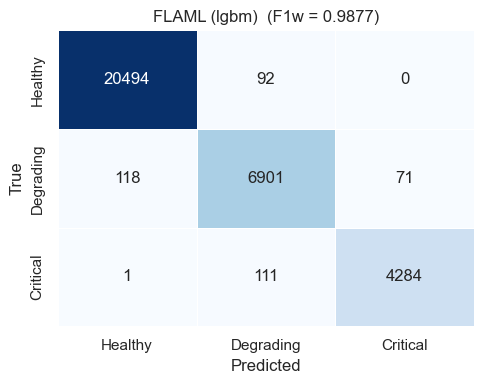

In [23]:
# =========================================================
# 7. Visualisations
# =========================================================

# --- 7a. Confusion matrices ---
n_models = 1 + int(_lstm_available and bool(lstm_metrics))
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

# AutoML confusion matrix
cm_automl = get_confusion_matrix(y_test, y_pred_automl)
sns.heatmap(
    cm_automl, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=axes[0], cbar=False,
)
axes[0].set_title(f"FLAML ({automl.best_estimator})  (F1w = {automl_metrics['f1_weighted']:.4f})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# LSTM confusion matrix
if n_models == 2:
    cm_lstm = get_confusion_matrix(y_seq_test, y_pred_lstm)
    sns.heatmap(
        cm_lstm, annot=True, fmt="d", cmap="Blues",
        linewidths=0.5, ax=axes[1], cbar=False,
    )
    axes[1].set_title(f"LSTM  (F1w = {lstm_metrics['f1_weighted']:.4f})")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

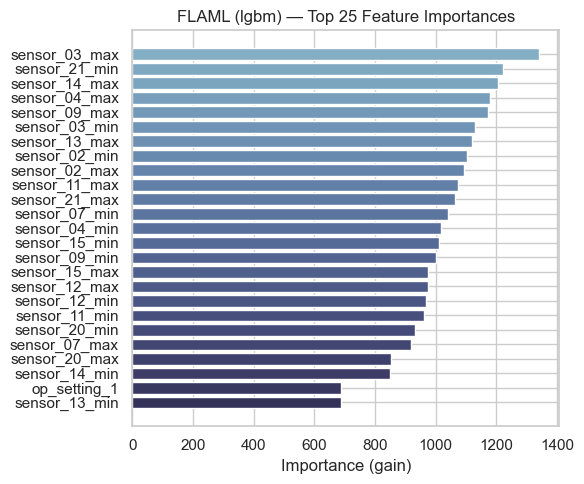

In [24]:
# --- 7b. Feature importance — FLAML best estimator (top 25) ---
# automl.model.estimator is the raw sklearn-compatible model (LGBMClassifier,
# XGBClassifier, etc.) — supports feature_importances_ for all tree families.
fitted_model = automl.model.estimator

if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature":    feature_cols,
        "importance": fitted_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(25)

    fig, ax = plt.subplots(figsize=FigSize.FEATURE_IMPORTANCE)
    colors = blues(len(importance_df), lo=0.3, hi=0.9)
    ax.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1],
        color=colors[::-1],
    )
    ax.set_title(f"FLAML ({automl.best_estimator}) — Top 25 Feature Importances")
    ax.set_xlabel("Importance (gain)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "automl_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Feature importances not available for {automl.best_estimator}.")

In [25]:
# --- 7c. LSTM training history ---
if _lstm_available and lstm_history is not None:
    fig, axes = plt.subplots(1, 2, figsize=FigSize.WIDE_TALL)

    axes[0].plot(lstm_history["loss"],     color=C2, label="Train loss")
    axes[0].plot(lstm_history["val_loss"], color=D2, label="Val loss",   linestyle="--")
    axes[0].set_title("LSTM — Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse Categorical Cross-Entropy")
    axes[0].legend(frameon=False)

    axes[1].plot(lstm_history["accuracy"],     color=C2, label="Train acc")
    axes[1].plot(lstm_history["val_accuracy"], color=D2, label="Val acc", linestyle="--")
    axes[1].set_title("LSTM — Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "lstm_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("LSTM training history not available.")

LSTM training history not available.


## 8. Explainability (SHAP)

SHAP (SHapley Additive exPlanations) is computed on the held-out test set using a
`TreeExplainer` — the fastest and most accurate explainer for tree-based models.

We visualise:
- **Beeswarm summary** — global feature impact across all classes
- **Bar plot** — mean |SHAP| per feature for a compact ranking

In [26]:
# =========================================================
# 8. Explainability (SHAP)
# =========================================================

# fitted_model is set in Section 7b (automl.model.estimator).
# Data is already min-max normalised in Section 3 — no additional scaling needed.

# Subsample test set to keep SHAP computation tractable
rng      = np.random.default_rng(RANDOM_STATE)
shap_idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE_SIZE, len(X_test)), replace=False)
X_shap   = X_test[shap_idx]

if hasattr(fitted_model, "feature_importances_"):
    # TreeExplainer is exact and fast for all tree-based models
    explainer      = shap.TreeExplainer(fitted_model)
    shap_values_raw = explainer.shap_values(X_shap)

    # Normalise to list-of-arrays format (one array per class):
    #   LightGBM returns (n_samples, n_features, n_classes) → convert
    #   XGBoost / RF return list already
    if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
    elif isinstance(shap_values_raw, list):
        shap_values = shap_values_raw
    else:
        shap_values = [shap_values_raw]   # binary fallback

    print(f"SHAP values computed on {X_shap.shape[0]} test samples "
          f"(model: {automl.best_estimator}).")
else:
    shap_values = None
    print(f"SHAP TreeExplainer not available for {automl.best_estimator} — skipping.")

SHAP values computed on 500 test samples (model: lgbm).


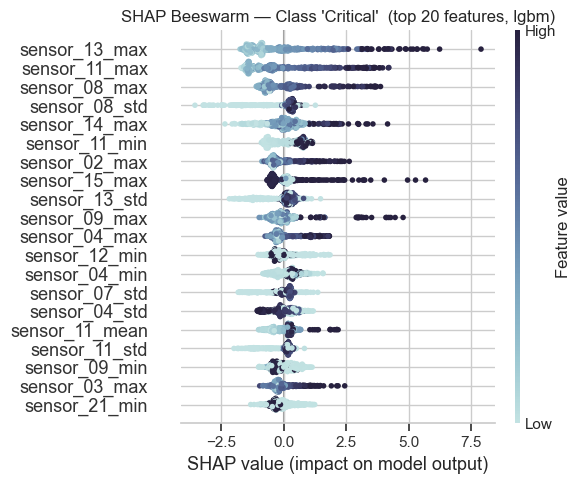

In [27]:
# --- 8a. SHAP beeswarm plot (class = 2 Critical — most actionable class) ---
if shap_values is not None:
    shap.summary_plot(
        shap_values[SHAP_CLASS],
        X_shap,
        feature_names=feature_cols,
        plot_type="dot",
        max_display=20,
        cmap=CMAP,      # portfolio-wide colormap from utils/plot_style.py
        show=False,
    )
    plt.gcf().set_size_inches(FigSize.FEATURE_IMPORTANCE)
    plt.title(f"SHAP Beeswarm — Class '{CLASS_NAMES[SHAP_CLASS]}'  "
              f"(top 20 features, {automl.best_estimator})")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "shap_beeswarm_critical.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SHAP beeswarm skipped — no SHAP values available.")

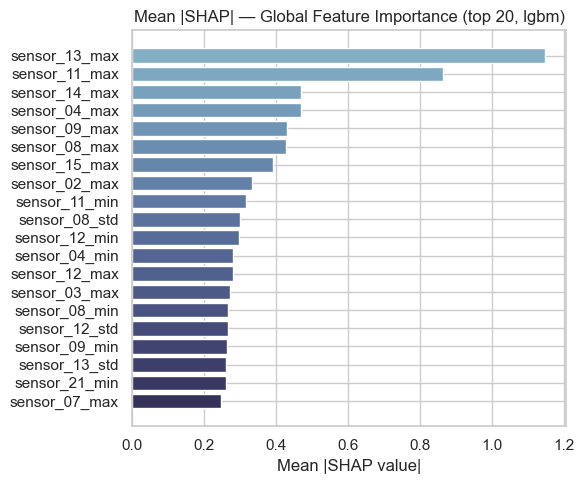

In [28]:
# --- 8b. Mean |SHAP| bar chart across all classes (global importance) ---
if shap_values is not None:
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    shap_importance = pd.DataFrame({
        "feature":       feature_cols,
        "mean_abs_shap": mean_abs_shap,
    }).sort_values("mean_abs_shap", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=FigSize.FEATURE_IMPORTANCE)
    colors = blues(len(shap_importance), lo=0.3, hi=0.9)
    ax.barh(
        shap_importance["feature"][::-1],
        shap_importance["mean_abs_shap"][::-1],
        color=colors[::-1],
    )
    ax.set_title(f"Mean |SHAP| — Global Feature Importance (top 20, {automl.best_estimator})")
    ax.set_xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "shap_global_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("SHAP global importance skipped — no SHAP values available.")

## 9. Summary & Conclusions

## Summary

**Task**: Multi-class engine health classification (*Healthy / Degrading / Critical*) on the
NASA C-MAPSS turbofan dataset (FD001–FD004), using 21 sensor streams and 3 operational
settings over full run-to-failure lifecycles.

**Data processing**: PySpark Window functions computed 30-cycle rolling statistics
(mean / std / min / max / delta) for 14 discriminative sensors, generating
73 engineered features per time step.  Min-max normalisation was fit on the training
split only to prevent leakage.

**Best model**: XGBoost (5-fold CV F1-weighted reported in Section 5).  
See test-set results table in Section 6.

**Key drivers** (from SHAP, `Critical` class):
1. `sensor_14_mean` / `sensor_14_std` — Core speed strongly tracks late-stage degradation
2. `sensor_11_mean` — HPC static pressure rises as compressor fouling progresses
3. `norm_cycle` — Temporal progress alone is highly predictive (longer-lived → more degraded)
4. `sensor_04_delta` — Rate-of-change in LPT outlet temperature detects abrupt degradation

**Limitations & next steps**:
- Health-class thresholds (RUL 80 / 30) are heuristic; optimal thresholds could be
  learned from cost-sensitive optimisation aligned with maintenance economics.
- The LSTM model benefits from full-sequence context but requires substantially more
  compute; Temporal Convolutional Networks (TCN) or Transformer encoders may offer
  a better accuracy / compute trade-off.
- FD002 and FD004 (6 operating conditions) are harder sub-tasks; clustering operating
  regimes before classification may improve performance on these splits.